In [1]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(".."))

df = pd.read_csv("../data/processed/dataset_c_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (14338, 9)


,image_id,street,city,n_citi,bed,bath,sqft,price,log_price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900,12.215528
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500,12.339291
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950,12.520701
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000,12.765688
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100,12.861258


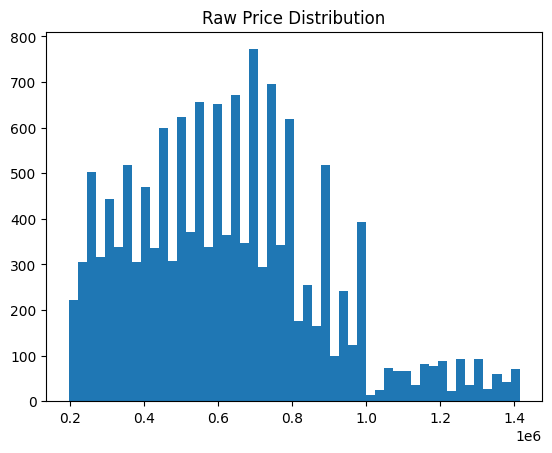

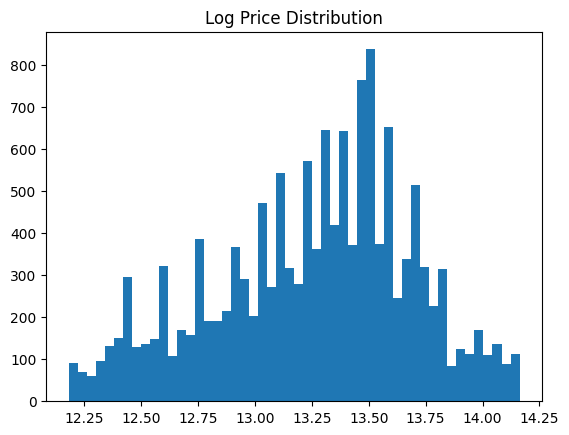

In [2]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=50)
plt.title("Raw Price Distribution")
plt.show()

plt.hist(df["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.show()

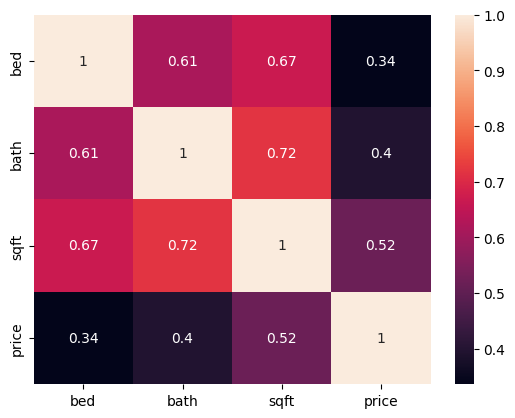

In [3]:
import seaborn as sns

sns.heatmap(df[["bed","bath","sqft","price"]].corr(), annot=True)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from src.models.structured_model import target_encode_city

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df, val_df, test_df, city_map = target_encode_city(
    train_df, val_df, test_df
)

train_df[["city", "city_encoded"]].head()

,city,city_encoded
9403,"Upland, CA",13.462044
1613,"Monterey Park, CA",13.608582
10880,"San Diego, CA",13.376026
14275,"Thousand Oaks, CA",13.697353
7308,"Canyon Lake, CA",13.423759


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import xgboost as xgb
import numpy as np

features = ["bed", "bath", "sqft", "city_encoded"]

X_train = train_df[features]
X_val = val_df[features]
y_train = train_df["log_price"]
y_val = val_df["log_price"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print("Linear R²:", r2_score(y_val, lr.predict(X_val_scaled)))

# Random Forest
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)
print("RF R²:", r2_score(y_val, rf.predict(X_val)))

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=300)
xgb_model.fit(X_train, y_train)
print("XGB R²:", r2_score(y_val, xgb_model.predict(X_val)))

Linear R²: 0.6668040549359773
RF R²: 0.7548916044432636
XGB R²: 0.752651115066467


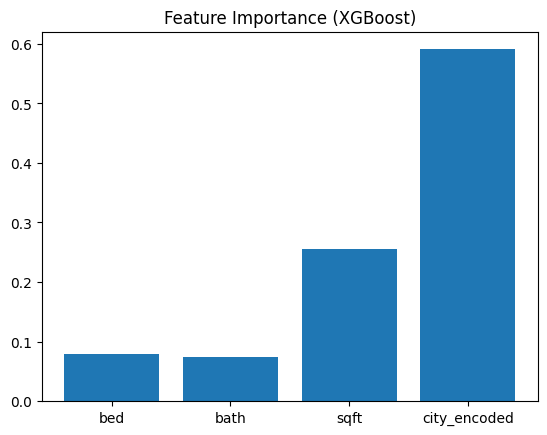

In [6]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
plt.bar(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [7]:
sample_input = pd.DataFrame([{
    "bed": 3,
    "bath": 2,
    "sqft": 1800,
    "city": "Los Angeles, CA"
}])

# apply encoding
sample_input["city_encoded"] = sample_input["city"].map(city_map)

X_sample = sample_input[["bed","bath","sqft","city_encoded"]]

pred_log = xgb_model.predict(X_sample)[0]
pred_price = np.exp(pred_log)

print("Predicted Price:", pred_price)

Predicted Price: 1146223.8
